# Build a multidimentional DataArray and Dataset


We made up some data in the simple example. Also, did you notice it's just one dimensional? Let's go through the excercise by building a multidimentional dataset.

We are going to start with some data that is just a bunch of normal numpy arrays, so we need to load numpy as well as xarray

### credit 

This lesson is from  Abernathy's book: (https://earth-env-data-science.github.io/lectures/xarray/xarray_intro.html). 


In [8]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Example: ARGO float

![](operation_park_profile.jpg)


![](statusbig.png)

Let's start by loading some real data. This is ARGO float data that contains temperature and salinity data {What is an Argo float? how does it take data?}. Those data are in the form of numpy arrays, or matricies. So, again, rows and columns. Let's draw on the board what the rows and columns are. They have coordinates like time, depth, latitude, longitude. Stuff you would expect to describe data collected in the ocean. 

Right now, when we load the data, it's going to be a collection of numpy arrays. They are all seperate objects, and what we'd like to do is stitch them together in a sensible way. To this we are going to create a DataArray, then a Dataset. 

In [ ]:
argo_data = np.load('argo_float_4901412.npz')

# I was asking gemini how the .npz file was structured, and it's basically like a lazy dictionaty
# The only difference between this and a dictionary is that the dictionary is going to load everything into memory all at once
# But this file won't load anything into memory until someone calls it, so yeah! 
# In my case, I'm just going to think of this as a dictionary, even though its a npz object, but it's similar enough I guess!

list(argo_data.keys())

['S', 'T', 'levels', 'lon', 'date', 'P', 'lat']

They are in this container because of how they are saved. Let's break each component out into it's own numpy array

In [ ]:
S = argo_data['S']
T = argo_data['T']
P = argo_data['P']
lat = argo_data['lat']
lon = argo_data['lon']
levels = argo_data['levels']
date = argo_data['date']

# Bracket notation runs the __getitem()__ method which 
# looks like object.__getitem__("ThingInBracket")
# So that's how it access the data using the bracket notation



for key in argo_data:
    print(key,'shape is', argo_data[key].shape)

AttributeError: 'NpzFile' object has no attribute 'S'

Remember from the previous notebook. 

The `DataArray` has these key properties:

* `data`: N-dimensional array (NumPy or dask) holding the array’s values, i.e. your actual data,

* `dims`: dimension names for each axis, just the names, like 'latitude' or 'longitude' or 'time'

* `coords`: dictionary-like container of arrays that label each point, i.e. the actual values of each axis like time or latitue or something

* `attrs`: ordered dictionary holding metadata, or 'attributes',  like the data units, person who collected, any of that stuff



Let's take the salinity `S` and create a DataArray for it

In [ ]:
da_salinity = xr.DataArray(S, dims=['levels','date'], coords={'levels': levels, 'date': date})

# So this would be a two dimensional DataArray, with dimensions level corresponding to row, and date corresponding to column
# And the coordinates are simply itself, meaning that yeah, the levels and date are corresponding to each element of the row and column. 


da_salinity

<xarray.DataArray (levels: 78, date: 75)> Size: 47kB
array([[35.6389389 , 35.51495743, 35.57297134, ..., 35.82093811,
        35.77793884, 35.66891098],
       [35.63393784, 35.5219574 , 35.57397079, ..., 35.81093216,
        35.58389664, 35.66791153],
       [35.6819458 , 35.52595901, 35.57297134, ..., 35.79592896,
        35.66290665, 35.66591263],
       ...,
       [34.91585922, 34.92390442, 34.92390442, ..., 34.93481064,
        34.94081116, 34.94680786],
       [34.91585922, 34.92390442, 34.92190552, ..., 34.93280792,
        34.93680954, 34.94380951],
       [34.91785812, 34.92390442, 34.92390442, ...,         nan,
        34.93680954,         nan]], shape=(78, 75))
Coordinates:
  * levels   (levels) int64 624B 0 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
  * date     (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 2014-0...

Ok, this is like the 1D fake bird data we made before, but now it's real 2D salinity data from the ocean. 

Let's see what xarray does if we ask it to make a simple plot:

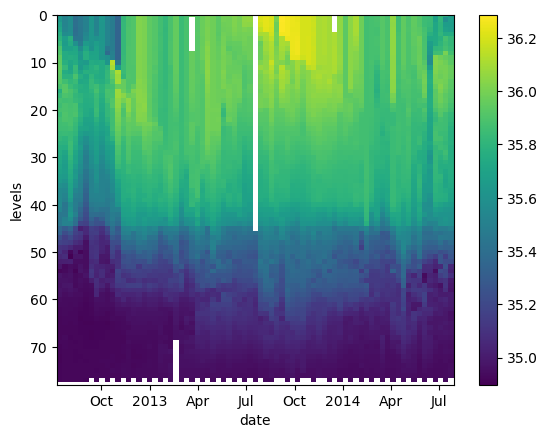

In [ ]:
da_salinity.plot() # sea of motion for color changes?
plt.ylim([78,0]);
# The ; makes it so you dont see the location of the plot in memory in output 

Nice! That is sort of amazing. Xarray knew that the salinity data is 2d - so by default it smartly made a pcolor plot (not a line plot or something). It also knew that time is on the x axis, and the 'levels' (depth) are on the y axis because the dimensions match. It also labeled out axis and formatted the dates.

But we aren't done with out DataArray yet. Remember the four parts of a DataArray? `data`, `dims`, `coords`, `attrs`. We can add other important information into the `attrs` part of the DataArray. Can you think of some important info?

In [ ]:
da_salinity.attrs['units'] = 'PSU'
# These are just attributes, unrelated to dimensions or coordinates. Since the program recognized the name "units" 
# and it also recognized the name "standard_name" It's going to include them in the plot.

# however, say for example I made a new attribute called "Coolness_factor" = "Really Cool"
# Mathplotlib definitely would not plot this on the chart! 

# Attributes is just more metadata, more information

da_salinity.attrs['standard_name'] = 'Sea Water Salinity'
#added the sttributes to the data rather than the colorbar itself.


da_salinity

<xarray.DataArray (levels: 78, date: 75)> Size: 47kB
array([[35.6389389 , 35.51495743, 35.57297134, ..., 35.82093811,
        35.77793884, 35.66891098],
       [35.63393784, 35.5219574 , 35.57397079, ..., 35.81093216,
        35.58389664, 35.66791153],
       [35.6819458 , 35.52595901, 35.57297134, ..., 35.79592896,
        35.66290665, 35.66591263],
       ...,
       [34.91585922, 34.92390442, 34.92390442, ..., 34.93481064,
        34.94081116, 34.94680786],
       [34.91585922, 34.92390442, 34.92190552, ..., 34.93280792,
        34.93680954, 34.94380951],
       [34.91785812, 34.92390442, 34.92390442, ...,         nan,
        34.93680954,         nan]], shape=(78, 75))
Coordinates:
  * levels   (levels) int64 624B 0 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
  * date     (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 2014-0...
Attributes:
    units:          PSU
    standard_name:  Sea Water Salinity
    TheTest:        Haha

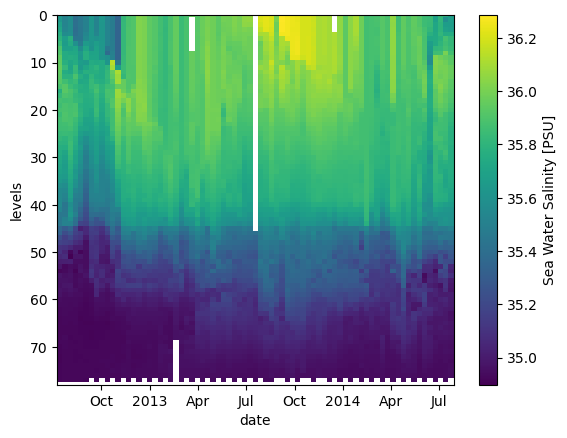

In [ ]:
da_salinity.plot()

# XArray has matplotlib inside of it (which is why we had to import it), that means I wouldn't have to make this plot by scratch
# I can just use Xarray and since everything is already named and nice, it's just going to make it for me! 

plt.ylim([78,0]);

# Datasets

xarray datasets can hold multiple DataArrays. This makes particular sense if the data in those multiple DataArrays share dimensions and coordinates. 

In our ARGO float example, both the Temperature and Salinity share the same dims and cords. So let's put them together into one dataset that holds all out float observational data. 

The Dataset constructor takes three arguments:

* `data_vars` should be a dictionary with each key as the name of the variable and each can be an already constructed DataArray, or a tuple that looks like this `(dims, data[, attrs])`

* `coords` should be a dictionary of the same form as data_vars.

* `attrs` should be a dictionary.

So here is an example for our argo data:


In [26]:

# DataArray = the np array with dimension labeling and other things 
# levels that would be the "ticks" kind of, like each one of the elements in the multi-dimensional array is going to be named according to levels
# date is just going to be all the dates that map to each one of the column elements.

# "levels" and "date" are just tje names of the dimensions

# A dataSET is just a colleciton of DataArrays. What even is a DataArray? It's simply more descriptive numpy arrays
# So yeah, a dataSET is just a nuch of dataARRAYS 

# In this case, salinity is one dataset, temperature is another, and pressure is another 
data_vars = {'salinity':(('levels','date'), S),'temperature': (('levels','date'),T), 'pressure':(('levels','date'),P)}

# since they're all 2 dimensional arrays, we can just assign the same coordinates to the dimensions! 
coords = {'levels':levels,'date':date}
argo = xr.Dataset(data_vars, coords)
argo

<xarray.Dataset> Size: 142kB
Dimensions:      (levels: 78, date: 75)
Coordinates:
  * levels       (levels) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
Data variables:
    salinity     (levels, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (levels, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (levels, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan

In [ ]:
argo.coords['lon'] = lon
argo

# Since this is a DataSet, this didn't crash on us. Normally it would have if we were doing this on a DataArray
# It would have crashed since the dimension of array does not equal the # of dimensions that we have 
# Given that we just added one

# So...
# Another rule to remember is whenever you use object.coords["blah"] = "blah" Xarray is going to assume you're making a whole new dimension in your DataSet


# As we can see in the dimensions, we have levels date and lon.. which is obviously not true we dont have three dimensions
# We're just trying to add ticks to an existing dimension, the dates!

<xarray.Dataset> Size: 142kB
Dimensions:      (levels: 78, date: 75, lon: 75)
Coordinates:
  * levels       (levels) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
  * lon          (lon) float64 600B -39.13 -37.28 -36.9 ... -33.83 -34.11 -34.38
Data variables:
    salinity     (levels, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (levels, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (levels, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan

Let's talk through what all those parts are telling us when we print out `argo`. 

What about the latitude and longitude? Those seem important and we'd like to use them for plotting and analysis later. They should be coordinates right? They should be the same size as one of the existing coordinates, either level or date. what do you think?

to add a new coordinate we can use:

In [ ]:
argo.coords['lon'] = lon
argo


Signature: argo.__getitem__(key: 'Mapping[Any, Any] | Hashable | Iterable[Hashable]') -> 'Self | DataArray'
Source:   
    def __getitem__(
        self, key: Mapping[Any, Any] | Hashable | Iterable[Hashable]
    ) -> Self | DataArray:
        """Access variables or coordinates of this dataset as a
        :py:class:`~xarray.DataArray` or a subset of variables or a indexed dataset.

        Indexing with a list of names will return a new ``Dataset`` object.
        """
        from xarray.core.formatting import shorten_list_repr

        if utils.is_dict_like(key):
            return self.isel(**key)
        if utils.hashable(key):
            try:
                return self._construct_dataarray(key)
            except KeyError as e:
                message = f"No variable named {key!r}."

                best_guess = utils.did_you_mean(key, self.variables.keys())
                if best_guess:
                    message += f" {best_guess}"
                else:
                    m

What we just did was add a whole new coordinate `lon`. But actually we know that each `lon` point is at a particular `date` location. So actually we can associate `lon` and `date`. To do that we set the dim of out new coord `lon` to be `date`. We can do the same for `lat`.

In [35]:
del argo['lon']
argo

# It's going to make an error since we already deleted the dimension long and its just going to say that 
# no such dimension exists but it's ignore and move on! 

<xarray.Dataset> Size: 142kB
Dimensions:      (levels: 78, date: 75)
Coordinates:
  * levels       (levels) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
Data variables:
    salinity     (levels, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (levels, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (levels, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan

In [59]:
# Here we go, now we're going to add coordinates lon and lat to the date dimension! 
#'lon', 'lat' is the name, while lon, lat is the actual values 
# remmeber, the elements must align

# There we go, you already know how it goes though! 

argo.coords['lon'] = ('date', lon)
argo.coords['lat'] = ('date', lat)
argo

<xarray.Dataset> Size: 143kB
Dimensions:      (levels: 78, date: 75)
Coordinates:
  * levels       (levels) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
    lat          (date) float64 600B 47.19 46.72 46.45 ... 42.6 42.46 42.38
    lon          (date) float64 600B -39.13 -37.28 -36.9 ... -34.11 -34.38
Data variables:
    salinity     (levels, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (levels, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (levels, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan

# Working with labeled data

We've built our nice dataset for the ARGO float. It has Temperature, salinity and pressure data. Those data also have label dimensions / coordinates that include level, date, lat, and lon. 

Now we are going to start to see some of the power of Xarray and how those labeled dimensions / coordinates let us make our analysis easier

## Selecting data (indexing)

Let's say we want to look at some subset of the temperature data (just a slice). We can use standard numpy notation to do this by indicating the number of the row and column we are interested in. Let's say we want to look at the second row and all columns ( so this is like a timeseries at a particular level)

using standard numpy indexing this would look like:

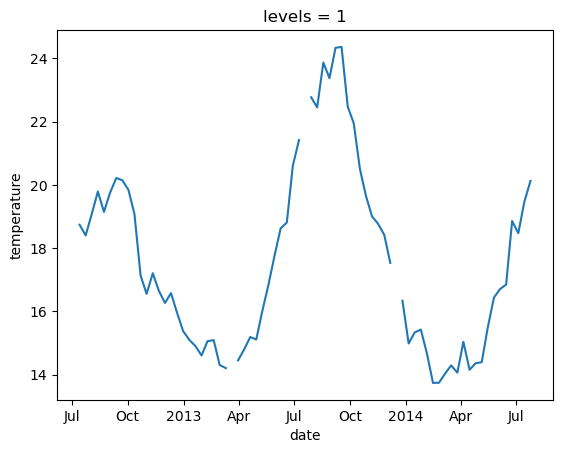

In [ ]:
#time series are a particular level

argo.temperature[1,:].plot();


# So basically using the numpy slicing notation, this is basically just saying 
# we're going to GO Into the Argo DataSet, 
# using dot notation we want the TEMPERATURE DataArray
# Because of 0 indexing, we want the SECOND row, and : just means we want all the values in that row

what about a particular depth profile? 

in standard numpy indexing:


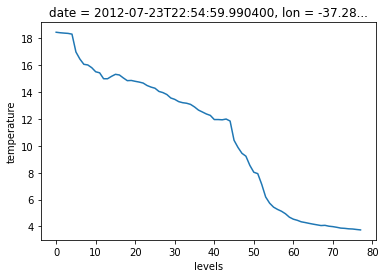

In [ ]:
# plot temp vs level for dive 1

# This is the same thing, we want the second COLUMN and we want all those values in that column. 

argo.temperature[:, 1].plot();



# Here's the part which makes this so useful, I'm taking notes right know and noticed how I called it row and column
# I did so since I had no idea what they represented, I simply forgot...

# But I'm going to assume really soon in this lesson, because we already labeled everything in terms of dimensions and assigned coordinates to those dimensions,
# I won't have to use the numpy slicing to get the subset of data that I want! 

That seems easy enough. But let's say you want to look at the temperature profile from a particular day. How are you going to do that? Well, you'd need to use the `date` dimension, look up the date you want, find it's index (meaning the number/position it comes in the list of dates) then put that index into the `argo.temperature[:,1].plot()` line. 

This isn't impossible. This is the kind of thing you do all the time in matlab. It's annoying and takes a few lines of code. 

But xarray solves this problem! using the `.sel()` method you can 'select' a part of your data based on the label. 

Here is how it works. let's get the profile on Oct 22 2012 by selecting based on the dimension `date`:

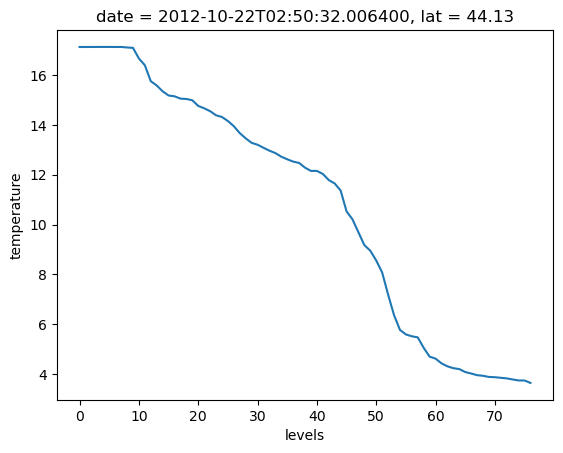

In [ ]:
argo.temperature.sel(date = '10-22-2012').plot();

# You can see the lat coordinate 

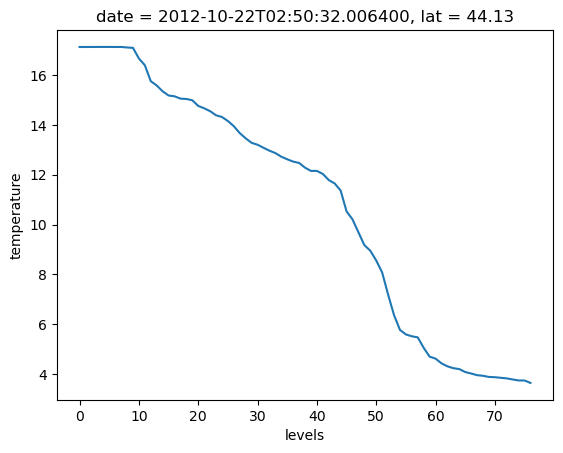

Signature:
argo.temperature.sel(
    indexers: 'Mapping[Any, Any] | None' = None,
    method: 'str | None' = None,
    tolerance=None,
    drop: 'bool' = False,
    **indexers_kwargs: 'Any',
) -> 'Self'
Docstring:
Return a new DataArray whose data is given by selecting index
labels along the specified dimension(s).

In contrast to `DataArray.isel`, indexers for this method should use
labels instead of integers.

Under the hood, this method is powered by using pandas's powerful Index
objects. This makes label based indexing essentially just as fast as
using integer indexing.

It also means this method uses pandas's (well documented) logic for
indexing. This means you can use string shortcuts for datetime indexes
(e.g., '2000-01' to select all values in January 2000). It also means
that slices are treated as inclusive of both the start and stop values,
unlike normal Python indexing.

.. warning::

  Do not try to assign values when using any of the indexing methods
  ``isel`` or ``sel``:

In [ ]:
argo.temperature.sel(date = '10-23-2012', method = 'nearest').plot();

argo.temperature.sel?

# Boom

In [58]:
argo

<xarray.Dataset> Size: 143kB
Dimensions:      (levels: 78, date: 75, lon: 75)
Coordinates:
  * levels       (levels) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
    lat          (date) float64 600B 47.19 46.72 46.45 ... 42.6 42.46 42.38
  * lon          (lon) float64 600B -39.13 -37.28 -36.9 ... -33.83 -34.11 -34.38
Data variables:
    salinity     (levels, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (levels, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (levels, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan

# Slicing data

We can also grab a bunch of days. Grabbing a bunch of consecutive data is typically called 'slicing'. We have to tell xarray that we want a slice of the `date` dimension. Again, this is new syntax, so don't be worried that you don't know it. You'll learn as you go from examples and from reading the documents for different packages.

let's get a couple months around our previous profile:

(78.0, 0.0)

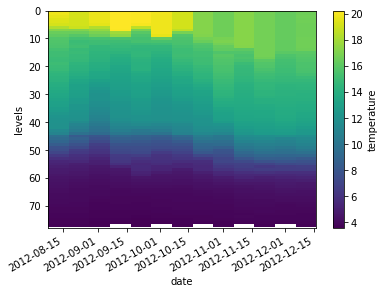

In [ ]:
argo.temperature.sel(date = slice('08-10-2012', '12-10-2012')).plot();

# So we're forced to use the slice() function since the other method of slicing would be to use the : notation
# however having a colon inside a parenthesis is strictly banned in python! 
# Therefore, we use slice()

# Anyways, even when doing Object[2:5] and slicing that way, Python turns your : into a Slice(2, 5) without you even noticing


plt.ylim([78,0])

You can also use `.sel()` on the whole dataset to, for example, grab all your data from one day:

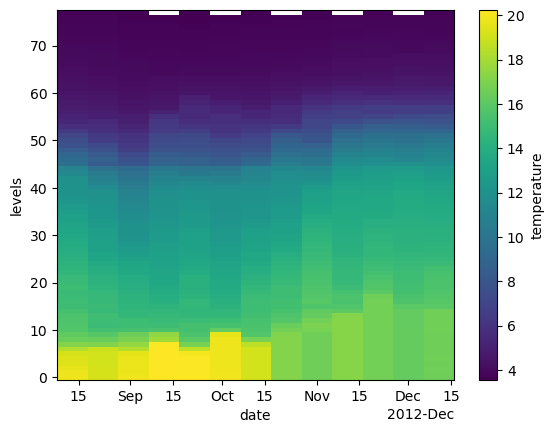

In [68]:
#argo_onedive = argo.sel(date = '10-22-2012') 
# # When we run only this one we get a 1D slice thus a 1D graph
 
argo_onedive = argo.sel(date = slice('08-10-2012', '12-10-2012'))
 # This is 2D hence we get the color plot from matplotlib

argo_onedive

argo_onedive.temperature.plot();

# Math

we can do any normal math on these DataArrays and Datasets:

<xarray.Dataset> Size: 190kB
Dimensions:      (levels: 78, date: 75)
Coordinates:
  * levels       (levels) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
    lat          (date) float64 600B 47.19 46.72 46.45 ... 42.6 42.46 42.38
    lon          (date) float64 600B -39.13 -37.28 -36.9 ... -34.11 -34.38
Data variables:
    salinity     (levels, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (levels, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (levels, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan
    temp_kelvin  (levels, date) float64 47kB 292.1 291.6 292.2 ... nan 276.9 nan

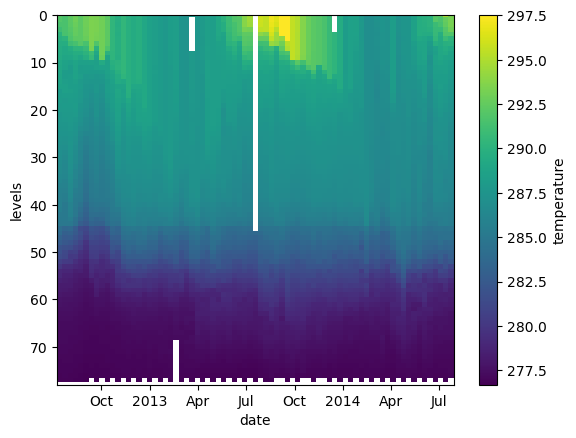

In [69]:
temp_kelvin = argo.temperature + 273.15

# We're able to do math since they're numpy arrays. 
# If you were to try to do this on a traditional Python table, yeah it would not work

temp_kelvin.plot()
plt.ylim([78,0])

argo['temp_kelvin'] = argo.temperature + 273.15
argo

you can combine DataArrays of the same size to get derived products like buoyancy:

<xarray.Dataset> Size: 236kB
Dimensions:      (levels: 78, date: 75)
Coordinates:
  * levels       (levels) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
    lat          (date) float64 600B 47.19 46.72 46.45 ... 42.6 42.46 42.38
    lon          (date) float64 600B -39.13 -37.28 -36.9 ... -34.11 -34.38
Data variables:
    salinity     (levels, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (levels, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (levels, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan
    temp_kelvin  (levels, date) float64 47kB 292.1 291.6 292.2 ... nan 276.9 nan
    bouyancy     (levels, date) float64 47kB -0.2073 -0.2075 ... -0.2324 nan

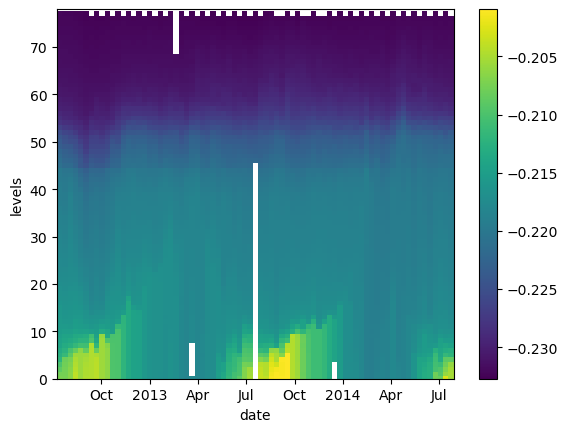

In [76]:
g = 9.8
alpha = 2e-4
beta  = -7e-4


# It's really convenient to do math operations using numpy arrays!

# argo = the DataSet
# argo.temperature one of the DataArrays in DataSet
# argo.salinity one of the DataArrays in DataSet 

# I'm putthing this here as just a reinforcement of how the DataSet was defined 
# data_vars = {'salinity':(('levels','date'), S),'temperature': (('levels','date'),T), 'pressure':(('levels','date'),P)}

# # since they're all 2 dimensional arrays, we can just assign the same coordinates to the dimensions! 
# coords = {'levels':levels,'date':date}
# argo = xr.Dataset(data_vars, coords)
# argo


bouyancy = g*(alpha*argo.temperature + beta*argo.salinity)

bouyancy.plot()

plt.ylim([78,0])
#or
plt.gca().invert_yaxis()


argo['bouyancy'] = g*(alpha*argo.temperature +beta*argo.salinity)

argo

we can do standard numpy math stuff like means, standard deviations, etc on dimensions.

We can average the whole dataset. xarray is smart, and it's going to average each of the data variabiles independantly:

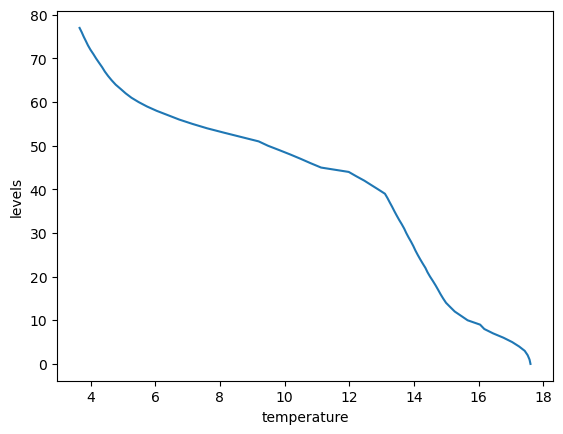

In [78]:
argo_mean = argo.mean(dim = 'date') 

# I forgot if date was the dimension of the row or the column, I think column, thus, that means 
# that this is getting the avergae of all the columns, the dimension of column


argo_mean

argo_mean.temperature.plot(y = 'levels');

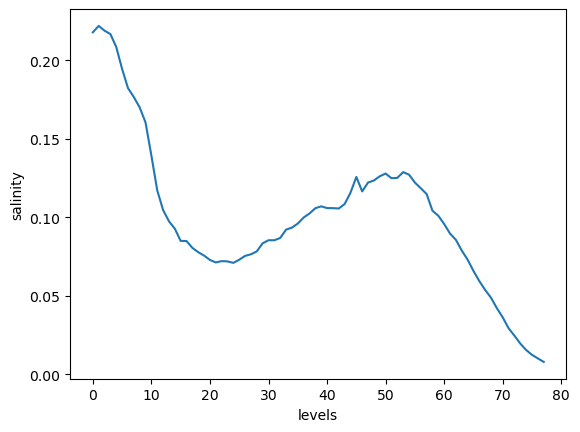

In [ ]:
argo_std = argo.std(dim = 'date')

# Getting that standard deviation I beleive 

argo_std.salinity.plot();

Task 1: The Bucket Builder
Create an xr.Dataset named mini_argo.

Put temp_data and salinity_data into the data_vars dictionary. Give them the dimensions ('levels', 'time').

Put depths and dates into the coords dictionary.

Hint method to look up: xr.Dataset?

Task 2: The Coordinate Trap
You need to add the lons array to your dataset as a coordinate. Remember the trap from your lesson! Make sure xarray knows that lons belongs to the time dimension, so it doesn't accidentally create a 3rd dimension.

Hint attribute to look up: mini_argo.coords?

Task 3: The Mature Coder
Using bracket notation (not dot notation), extract just the temperature DataArray and save it to a new variable called temp_only.

Hint: []

Task 4: The Time Slicer
Using the .sel() method and a slice() object, grab a slice of your temp_only data from "2026-01-02" to "2026-01-04".

Hint method to look up: temp_only.sel? and slice?

Task 5: The Math & The Plot
Take the entire mini_argo dataset and calculate the average (mean) across the 'time' dimension. Once you have that mean dataset, plot the average temperature profile.

Hint methods to look up: .mean? and .plot?

There are a lot more cool math/analysis functions we can do with xarray. We will see more of them later on.

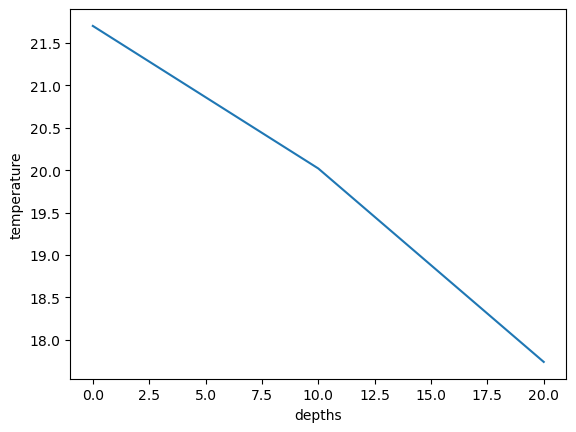

In [ ]:
# Breakout / exercise 02
# I just made Gemini Pro generate a small easy exercise for me to complete: 

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# 1. The Labels (Coordinates)
dates = pd.date_range("2026-01-01", periods=5)
depths = [0, 10, 20] 

# 2. The Data (3 rows of depths, 5 columns of dates)
temp_data = np.array([
    [22.1, 22.0, 21.8, 21.5, 21.1],
    [20.5, 20.3, 20.0, 19.8, 19.5],
    [18.2, 18.0, 17.8, 17.5, 17.2]
])

salinity_data = np.array([
    [35.1, 35.2, 35.2, 35.3, 35.4],
    [35.3, 35.4, 35.4, 35.5, 35.5],
    [35.5, 35.6, 35.6, 35.7, 35.8]
])

# 3. Drifting location over time (1D array)
lons = np.array([-118.1, -118.2, -118.3, -118.4, -118.5])

data_vars = {
    "temperature": (("depths", "dates"), temp_data), 
    "salinity_data": (("depths", "dates"), salinity_data)
}

coords = {
    "dates": dates, 
    "depths": depths
}

mini_argo = xr.Dataset(data_vars, coords)

# now gotta add the longitude as coordinates to the dates dimension

mini_argo.coords["lons"] = ("dates", lons)

# getting temperature only

temperature_only = mini_argo["temperature"]

# Getting a range of data 

temp_sliced = temperature_only.sel(dates = slice("2026-01-02", "2026-01-04"))

# getting average

mini_argo_mean = mini_argo.mean(dim = "dates")

avg_temp_profile = mini_argo_mean["temperature"]

avg_temp_profile.plot();



# Good for memorizing these functions and the syntax and other stuff, yeah yeah

# moving onto the next jupytr notebook! 

SyntaxError: invalid syntax (3845788349.py, line 1)